# Tsanfleuron Project (2019-2020)

### Data preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# import from package 'geone'
from geone import img
import geone.imgplot as imgplt
import geone.customcolors as ccol
import geone.deesseinterface as dsi

import pickle
import time

In [2]:
def gis_to_img(path, gisText):
    from geone import img
    import pickle
    
    with open(path+gisText,'r') as txt:
        lines = txt.readlines()
        infos = {}
        
        for i, line in enumerate(lines):
            line = line.split()
            if line[0] == '-1':
                startData = i
                break
            else:
                infos[line[0]] = line[1]
                
        dataTxt = []        
        for dataLines in lines[startData:]:
            dataTxt.append(dataLines)
                
    with open(path+'gslib/'+gisText[:-3]+'gslib', 'w') as txtOut:
        txtOut.write('{0} {1} 1 {4} {4} 1 {2} {3} 0\n'.format(infos['ncols'], infos['nrows'], infos['xllcorner']
                                                      ,infos['yllcorner'],infos['cellsize']))
        txtOut.write('1\n')
        txtOut.write('alt\n')
        for positionLine in range(len(dataTxt)):
            dataSplit = dataTxt[-positionLine-1].split()
            
            for positionSplit in range(len(dataSplit)):
                data = dataSplit[positionSplit]
                if data == infos['NODATA_value']:
                    txtOut.write(str('nan\n'))
                else:
                    txtOut.write(data+'\n')
    print('Gslib is created!')
    
    geoneImg = img.readImageGslib(path+'gslib/'+gisText[:-3]+'gslib')
    print('Geone Img is created!!')
    
    with open(path+'pickle/'+gisText[:-3]+'pickle','wb') as filePickle:
        pickle.dump(geoneImg,filePickle , pickle.HIGHEST_PROTOCOL)
    print('Pickle file is created!!!')        
    
    return 

In [3]:
file_name_ti   = ['ti_alt1_drone.txt','ti_alt1_alti3d.txt', 'ti_alt2_alti3d.txt']
file_name_mask = ['glacier_mask_2m.txt','Glacier_Mask_10cent.txt'] 
file_name_dem  = ['dsm_alt3d_2m.txt','dsm_drone_10cm.txt']
file_name_hd   = ['BedRock_GPR.csv','BedRock_MNT.csv']

In [ ]:
for ti in file_name_ti:
    gis_to_img('TI/',ti)
#for mask in file_name_mask:
#    gis_to_img(pathData+'Mask/',mask)

Gslib is created!


In [ ]:
with open('TI/pickle/ti_alt1_alt3d.pickle','br') as file:
    ti = pickle.load(file)

In [4]:
imgT= img.readImageGslib('TI/gslib/ti_alt1_drone.gslib')

In [93]:
test =img.readImageGslib('test.gslib')

In [6]:
with open('TI/pickle/ti_alt1_drone.pickle','wb') as file:
    pickle.dump(imgT, file, pickle.HIGHEST_PROTOCOL)

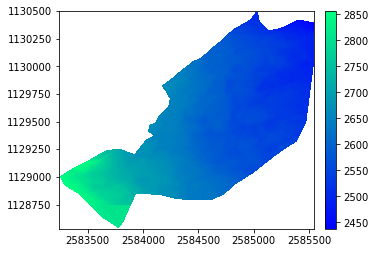

In [5]:
imgplt.drawImage2D(imgT,cmap='winter')